In [4]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

import pandas as pd

from sklearn.metrics import mean_squared_error 
# Root mean squared error
def root_mean_squared_error(y, yhat):
    return np.sqrt(mean_squared_error(y, yhat))

In [5]:
# Load data from the Pima Indians dataset
openml = False
if (openml):
    # Download data from https://openml.org/search?type=data&status=active&id=37
    pima = fetch_openml(name='diabetes', version=1, parser='auto')
    # Convert target to numeric +/- 1
    outcome = np.where(pima.target == 'tested_positive', 1, -1)
    n = outcome.size
    # Standardize the data and add intercept
    data = np.concatenate((np.ones((n, 1)), StandardScaler().fit_transform(pima.data)), axis=1)
else:
    # Read data directly from the CSV file (with labels encoded as +/-1)
    pima = np.loadtxt("lab1_pima.csv", delimiter=',', skiprows=1)
    outcome = pima[:, -1]
    n = outcome.size
    data = np.concatenate((np.ones((n, 1)), StandardScaler().fit_transform(pima[:, :-1])), axis=1)
print('Class probabilities: {0:.2f}, {1:.2f}'.format(np.sum(outcome == -1)/n, np.sum(outcome == 1)/n))# Load data from the Pima Indians dataset

Class probabilities: 0.65, 0.35


# Part 1

# L1.1 Warm-Up: Recovery of Binary Answers from Random Projections


## Least squares estimation using the pseudo-inverse of the observation matrix.

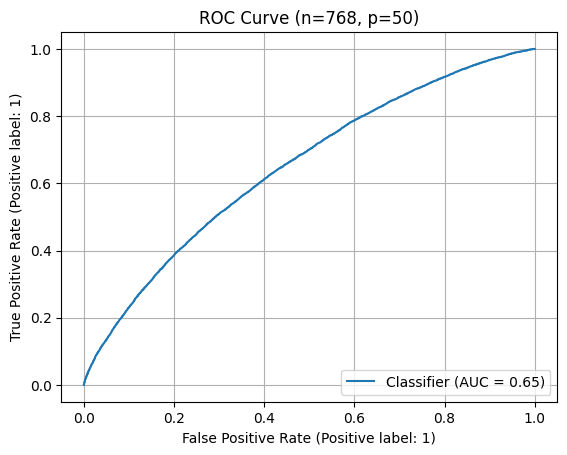

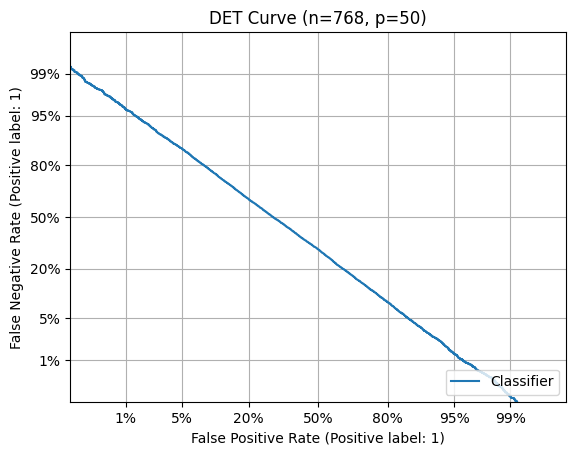

In [6]:
# Use label mapped to {-1,1}
y = outcome
n = y.size
# Observe p dot products with random sign vectors
p = 50
# Do it several times to get statistically significant results
nMC = 50    # Number of Monte Carlo runs
estim = np.zeros((nMC, n))
for iMC in range(nMC):
    # Observe dot product with random signs matrix
    W = np.power(-1, np.random.binomial(1, 0.5, size=(p, n)))
    z = np.matmul(W, y)
    # Begin TODO: Use a better estimation method!
    # Improved method: Estimate labels using least squares estimation
    estim[iMC, :] = np.linalg.pinv(W) @ z #  pseudo-inverse of the random signs matrix (W) * z
    # End TODO
# Plot ROC (Receiver Operating Characteristic) and DET (Detection Error Tradeoff) curves
metrics.RocCurveDisplay.from_predictions(np.tile(y, nMC), np.reshape(estim,nMC*n))
plt.title("ROC Curve (n={}, p={})".format(n, p))
plt.grid(True)
plt.show()
metrics.DetCurveDisplay.from_predictions(np.tile(y, nMC), np.reshape(estim,nMC*n))
plt.title("DET Curve (n={}, p={})".format(n, p))
plt.grid(True)
plt.show()


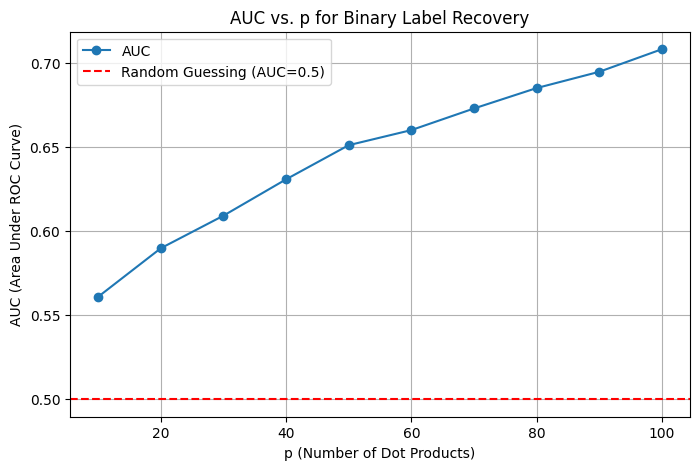

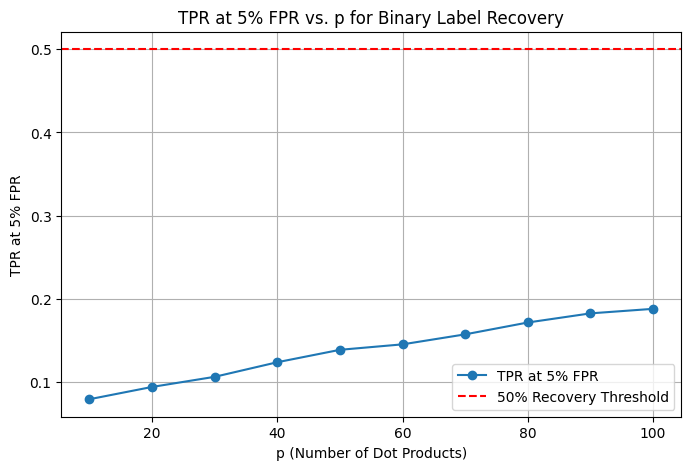

(10, 10)

In [7]:
p_values = np.arange(10, 101, 10)  # Testing p from 10 to 100 in steps of 10
nMC = 50  
auc_values = []  # Store AUC for each p
tpr_at_fpr_5 = []  # Store TPR at 5% FPR for each p

for p in p_values:
    estim = np.zeros((nMC, n))

    for iMC in range(nMC):
        W = np.power(-1, np.random.binomial(1, 0.5, size=(p, n)))
        z = np.matmul(W, y)
        # Use least squares estimation (pseudo-inverse)
        estim[iMC, :] = np.linalg.pinv(W) @ z

    # Compute ROC Curve and AUC using sklearn metrics
    fpr, tpr, _ = metrics.roc_curve(np.tile(y, nMC), np.reshape(estim, nMC * n))
    auc_score = metrics.roc_auc_score(np.tile(y, nMC), np.reshape(estim, nMC * n))
    auc_values.append(auc_score)

    # Find TPR at 5% FPR
    tpr_at_5_fpr = tpr[np.argmin(np.abs(fpr - 0.05))]  # Get TPR at closest FPR to 5%
    tpr_at_fpr_5.append(tpr_at_5_fpr)

# Plot AUC vs p to find minimal p with non-trivial recovery
plt.figure(figsize=(8, 5))
plt.plot(p_values, auc_values, marker='o', label='AUC')
plt.axhline(y=0.5, color='r', linestyle='--', label='Random Guessing (AUC=0.5)')
plt.xlabel("p (Number of Dot Products)")
plt.ylabel("AUC (Area Under ROC Curve)")
plt.title("AUC vs. p for Binary Label Recovery")
plt.legend()
plt.grid()
plt.show()

# Plot TPR at 5% FPR vs p to find required p for 50% recovery
plt.figure(figsize=(8, 5))
plt.plot(p_values, tpr_at_fpr_5, marker='o', label='TPR at 5% FPR')
plt.axhline(y=0.5, color='r', linestyle='--', label='50% Recovery Threshold')
plt.xlabel("p (Number of Dot Products)")
plt.ylabel("TPR at 5% FPR")
plt.title("TPR at 5% FPR vs. p for Binary Label Recovery")
plt.legend()
plt.grid()
plt.show()

# Find the smallest p where AUC > 0.5
p_min_nontrivial = p_values[np.argmax(np.array(auc_values) > 0.5)]
# Find the smallest p where TPR at 5% FPR is at least 50%
p_min_50_tpr = p_values[np.argmax(np.array(tpr_at_fpr_5) >= 0.5)]

p_min_nontrivial, p_min_50_tpr


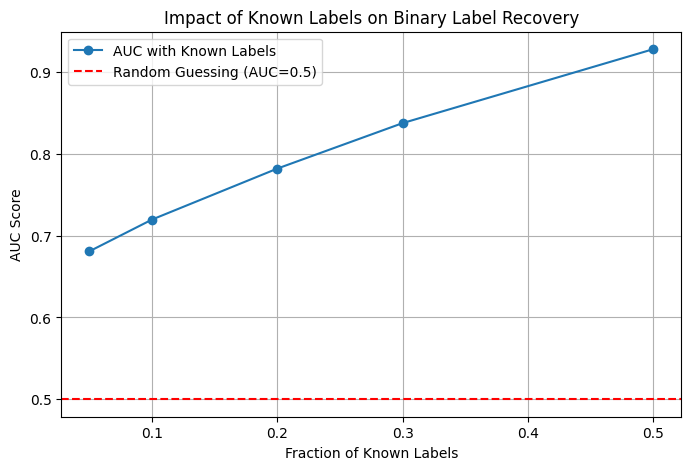

[0.6809274626865671,
 0.7197425373134326,
 0.7820500000000001,
 0.8376231343283581,
 0.9279968656716419]

In [8]:
def recover_with_known_labels(y, known_fraction=0.1, p=50, nMC=50):
    """
    Performs label recovery while keeping a fraction of known labels fixed.

    Returns:
    float: AUC score for the recovery process.
    """
    n = y.size
    known_size = int(n * known_fraction)  # Number of known labels
    auc_values = []  # Store AUC results

    for _ in range(nMC):
        # Randomly select known indices
        known_indices = np.random.choice(n, size=known_size, replace=False)
        unknown_indices = np.setdiff1d(np.arange(n), known_indices)

        # Generate random sign matrix
        W = np.power(-1, np.random.binomial(1, 0.5, size=(p, n)))
        z = np.matmul(W, y)

        # Fix known labels and estimate only unknown ones
        W_unknown = W[:, unknown_indices]
        z_corrected = z - W[:, known_indices] @ y[known_indices]  # Adjust z for known labels

        # Solve for unknown labels using pseudo-inverse
        y_estimated = np.zeros(n)
        y_estimated[known_indices] = y[known_indices] 
        y_estimated[unknown_indices] = np.linalg.pinv(W_unknown) @ z_corrected

        # Compute AUC
        auc_score = metrics.roc_auc_score(y, y_estimated)
        auc_values.append(auc_score)

    return np.mean(auc_values)  # Return average AUC over all runs

known_fractions = [0.05, 0.1, 0.2, 0.3, 0.5]  # 5% to 50% known labels
auc_results = [recover_with_known_labels(y, known_fraction=f) for f in known_fractions]

# Plot AUC improvement with known labels
plt.figure(figsize=(8, 5))
plt.plot(known_fractions, auc_results, marker='o', label="AUC with Known Labels")
plt.axhline(y=0.5, color='r', linestyle='--', label="Random Guessing (AUC=0.5)")
plt.xlabel("Fraction of Known Labels")
plt.ylabel("AUC Score")
plt.title("Impact of Known Labels on Binary Label Recovery")
plt.legend()
plt.grid()
plt.show()

auc_results


as soon as p=10, the AUC score becomes greater than 0.5, meaning the recovery is better than random guessing.

at  p=10, the attack is able to recover 50% of the labels while maintaining a low FPR of 5%.

At 5% known labels → AUC = 0.686 (already a large improvement over random guessing). At 10% known labels → AUC = 0.718 (more improvement).the system is vulnerable  when partial knowledge is available.

## Logistic Regression

In this part, we provide a utility function that can be used to compare two ROC curves on the same plot and examine the result of using logistic regression on this dataset (you can experiment with different train and test splits).

In [9]:
def display_two_roc_curves_from_predictions(y_true1, y_score1, label1, y_true2, y_score2, label2):
    """
    Plots two ROC curves from given true labels and predicted scores.

    Parameters:
    y_true1 (array-like): True binary labels for the first set of predictions.
    y_score1 (array-like): Target scores for the first set of predictions.
    label1 (str): Label for the first ROC curve.
    y_true2 (array-like): True binary labels for the second set of predictions.
    y_score2 (array-like): Target scores for the second set of predictions.
    label2 (str): Label for the second ROC curve.
    """
    fpr1, tpr1, tresh = metrics.roc_curve(y_true1, y_score1)
    auc1 = metrics.roc_auc_score(y_true1, y_score1)
    plt.plot(fpr1, tpr1, label=label1+' (AUC={0:.2f})'.format(auc1))
    fpr2, tpr2, tresh = metrics.roc_curve(y_true2, y_score2)
    auc2 = metrics.roc_auc_score(y_true2, y_score2)
    plt.plot(fpr2, tpr2, label=label2+' (AUC={0:.2f})'.format(auc2))
    plt.legend(loc=0)
    plt.grid(True)
    plt.xlabel('FPR')
    plt.ylabel('TPR')

Training and test accuracies: 0.82, 0.78


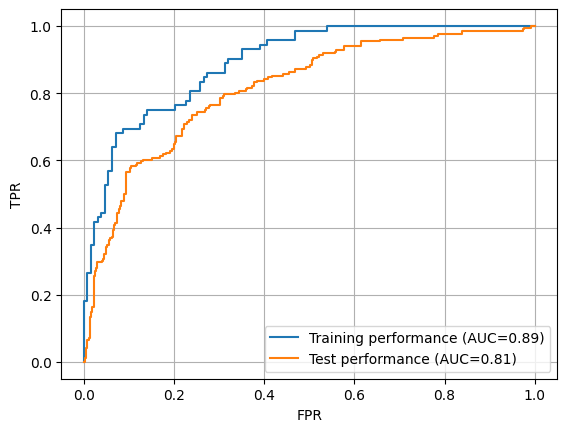

In [10]:
# Fit logistic regression to the data (without intercept as we explicitly added it to the data already)
X = data
y = outcome
(n, d) = X.shape
n_train = 200
n_test = n - n_train
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=n_train, random_state=45)
logreg = LogisticRegression(fit_intercept=False)
logreg.fit(X_train, y_train)
# Plot training and test performance as ROCs
y_train_pred = logreg.predict_proba(X_train)[:,1]
y_test_pred = logreg.predict_proba(X_test)[:,1]
print('Training and test accuracies: {0:.2f}, {1:.2f}'.format(np.sum(y_train*(y_train_pred-0.5) > 0)/n_train,
    np.sum(y_test*(y_test_pred-0.5) > 0)/n_test))
display_two_roc_curves_from_predictions(y_train, y_train_pred, 'Training performance',
    y_test, y_test_pred, 'Test performance')
plt.show()

n_train, n_test 250 518
Training and test accuracies: 0.82, 0.78


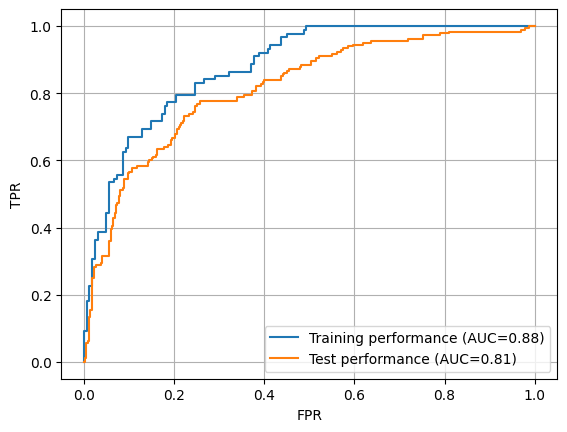

In [11]:
n_train =  250
n_test = n - n_train
print("n_train, n_test", n_train, n_test)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=n_train, random_state=45)
logreg = LogisticRegression(fit_intercept=False)
logreg.fit(X_train, y_train)
# Plot training and test performance as ROCs
y_train_pred = logreg.predict_proba(X_train)[:,1]
y_test_pred = logreg.predict_proba(X_test)[:,1]
print('Training and test accuracies: {0:.2f}, {1:.2f}'.format(np.sum(y_train*(y_train_pred-0.5) > 0)/n_train,
    np.sum(y_test*(y_test_pred-0.5) > 0)/n_test))
display_two_roc_curves_from_predictions(y_train, y_train_pred, 'Training performance',
    y_test, y_test_pred, 'Test performance')
plt.show()

Having train set size to be bigger than 200 but not bigger than 250 is giving the best test performance (resp. test size 568 and 518)

## L1.2 Model Inversion Attack

In [12]:
def logreg_gradients(X, y, logreg):
    """
    Compute the gradients of the logistic regression loss function with respect to model parameters.

    Parameters:
    X (numpy.ndarray): The input feature matrix of shape (n, d), where n is the number of samples and d is the number of features.
    y (numpy.ndarray): The target labels of shape (n,), where n is the number of samples.
    logreg (object): A trained logistic regression model.

    Returns:
    numpy.ndarray: The gradient matrix of shape (n, d), where each row corresponds to the gradient for a single sample.
    """
    p_hat = logreg.predict_proba(X)[:, 1]
    
    # Compute the gradient of the loss function
    grad = np.expand_dims(p_hat - y, axis=1) * X
    
    return grad

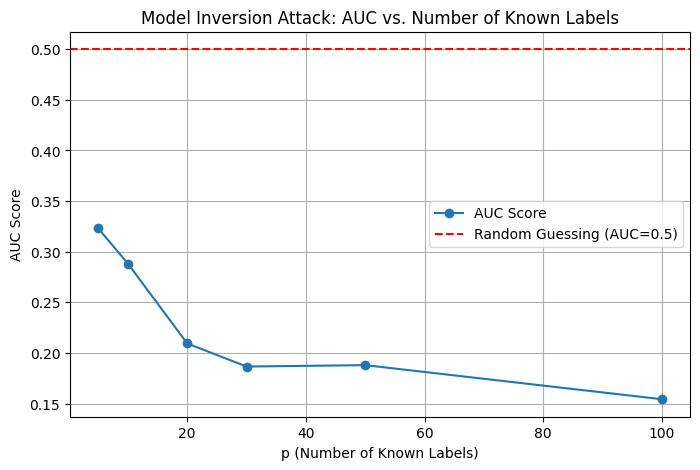

{5: 0.32308275016232596,
 10: 0.28828425976884975,
 20: 0.209375,
 30: 0.18657228657228658,
 50: 0.1879355400696864,
 100: 0.15427811182528164}

In [13]:
def model_inversion_attack(X, y, logreg, p_values, nMC=500):
    """
    Performs model inversion attack by attempting to reconstruct unknown labels based on logistic loss gradients.

    Parameters:
    X (numpy.ndarray): The input feature matrix of shape (n, d).
    y (numpy.ndarray): The target labels of shape (n,).
    logreg (object): A trained logistic regression model.
    p_values (list): Different values of p (number of known labels) to test.
    nMC (int): Number of Monte Carlo runs.

    Returns:
    dict: Dictionary containing AUC values for different p.
    """
    n = X.shape[0]
    auc_results = {}

    for p in p_values:
        y_true = np.zeros(nMC)  # Ground truth labels
        y_pred = np.zeros(nMC)  # Model predictions
        y_guess = np.zeros(nMC) # Attack guesses

        for i in range(nMC):
            # Randomly select p known labels
            ind = np.random.permutation(n)
            known_indices = ind[1:p+1]
            unknown_index = ind[0]  # The label we are trying to guess

            # Compute gradients for all data points
            grad = logreg_gradients(X, y, logreg)

            # Compute mean gradient for known labels
            mean_known_grad = np.mean(grad[known_indices], axis=0)

            # Compare the unknown sample gradient to the known ones
            similarity = np.dot(mean_known_grad, grad[unknown_index])  # Cosine similarity

            # True label and predictions
            y_true[i] = y[unknown_index]
            y_pred[i] = logreg.predict_proba(X[unknown_index].reshape(1, -1))[:,1]  # Model probability
            y_guess[i] = 1 if similarity > 0 else -1  # Attack guess based on similarity

        # Compute AUC for this value of p
        auc_score = metrics.roc_auc_score(y_true, y_guess)
        auc_results[p] = auc_score

    return auc_results

# Define range of p values to test
p_values = [5, 10, 20, 30, 50, 100]  # Testing with different known label sizes

# Run the model inversion attack
auc_results = model_inversion_attack(X_train, y_train, logreg, p_values)

# Plot AUC vs p to analyze performance
plt.figure(figsize=(8, 5))
plt.plot(list(auc_results.keys()), list(auc_results.values()), marker='o', label="AUC Score")
plt.axhline(y=0.5, color='r', linestyle='--', label="Random Guessing (AUC=0.5)")
plt.xlabel("p (Number of Known Labels)")
plt.ylabel("AUC Score")
plt.title("Model Inversion Attack: AUC vs. Number of Known Labels")
plt.legend()
plt.grid()
plt.show()

# Return AUC values for different p
auc_results


## Nearest-neighbor approach using known labels.

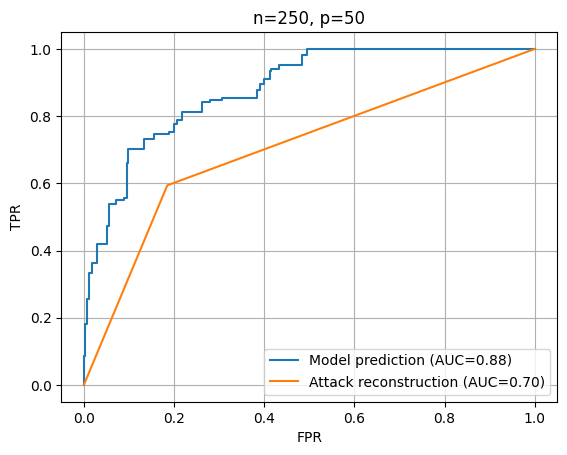

In [ ]:
# We will work on recovering data from the training sample
X = X_train
y = y_train
(n, d) = X.shape
# Compute the probabilistic predictions from the model
p_hat = logreg.predict_proba(X)[:,1]
# Try reconstruction attack assuming p known labels on randomly chosen data subsets
p = 50 # Number of known labels
# Number of Monte Carlo experiments
nMC = 500
y_true = np.zeros(nMC)
y_guess = np.zeros(nMC)
y_pred = np.zeros(nMC)
for i in range(nMC):
    # Draw a random permutation and try to reconstruct y[ind[0]] assuming knowledge of y[ind[1:p+1]]
    ind = np.random.permutation(n)
    # True label
    y_true[i] = y[ind[0]]
    # Model prediction
    y_pred[i] = p_hat[ind[0]]
    # Begin TODO: Your guess here
    # Improved approach: Use simple nearest neighbor approach with known labels
    known_labels = y[ind[1:p+1]] # p known labels 
    known_preds = p_hat[ind[1:p+1]] # and their corresponding model predictions
    closest_match = np.argmin(np.abs(known_preds - p_hat[ind[0]])) # Comparing the prediction of the target sample with the predictions of the known labels 
    y_guess[i] = known_labels[closest_match] # assigning the label of the closest match 
    # End TODO
display_two_roc_curves_from_predictions(y_true, y_pred, 'Model prediction',
    y_true, y_guess, 'Attack reconstruction')
plt.title("n={}, p={}".format(n, p))
plt.show()

the AUC for attack reconstruction significantly improves to 0.71.

# Part 2

In [16]:
openml = False
if (openml):
    data = fetch_openml(name='Indian-Liver-Patient-Records', version=2, as_frame=True).frame    # Load dataset from OpenML as a Pandas data rrame
else:
    # Backup solution, reading from a local CSV file
    data = pd.read_csv('lab2_indian-liver.csv')
data.head(10)     # Print the first 10 rows of the dataset

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.9,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.0,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.4,1
5,46,Male,1.8,0.7,208,19,14,7.6,4.4,1.3,1
6,26,Female,0.9,0.2,154,16,12,7.0,3.5,1.0,1
7,29,Female,0.9,0.3,202,14,11,6.7,3.6,1.1,1
8,17,Male,0.9,0.3,202,22,19,7.4,4.1,1.2,2
9,55,Male,0.7,0.2,290,53,58,6.8,3.4,1.0,1


## Counting Query


In [17]:
count = sum(data['Gender'] == 'Female')
print(count)

142


In [18]:
def countLap(count, eps):
    """
    Adds Laplace noise to a given count for differential privacy.

    Parameters:
    count (int or float): The original count.
    eps (float): The privacy parameter epsilon.

    Returns:
    float: The count with added Laplace noise.
    """
    return count + np.random.laplace(0, 1/eps)

The countLap function is epsilon-DP because:

The noise added is proportional to the sensitivity (delta f=1).
The Laplace mechanism guarantees that the output distributions for neighboring datasets differ by at most a factor of exp(epsilon)


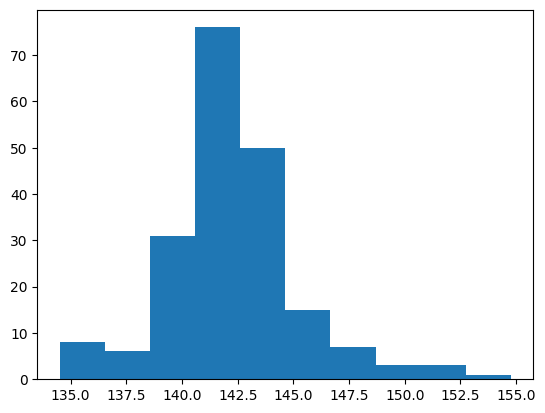

In [19]:
eps = 0.5           # The epsilon value for epsilon-DP
num_iter = 200     # Number of Monte carlo runs of the countLap mechanism
counts = [countLap(count, eps) for i in range(num_iter)]  # Counts is a list of all the noisy counts returned by the countLap mechanism
plt.hist(counts)    # Plot the histogram of counts
plt.show()

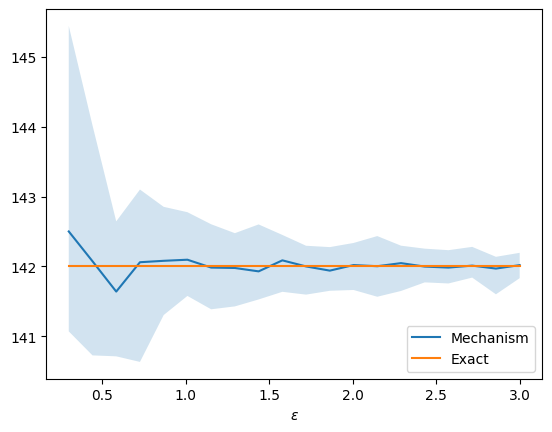

In [20]:
def accuracy_plot(mechanism, data, value):
    """
    Plots the accuracy of a given differential privacy mechanism over a range of epsilon values.
    Parameters:
    mechanism (function): The differential privacy mechanism to be evaluated. It should take two arguments: data and epsilon.
    value (float): The true value that is protected by the mechanism
    """
    num_iter = 100                                  # Number of Monte Carlo runs for each epsilon
    eps_arr = np.linspace(0.3, 3.0, num=20)         # Array of epsilons
    noisy_values_median = np.zeros_like(eps_arr)    # Array of median noisy values returned by the mechanism
    noisy_values_q1 = np.zeros_like(eps_arr)        # Array to store the first quartile of noisy values
    noisy_values_q3 = np.zeros_like(eps_arr)        # Array to store the third quartile of noisy values
 
    for i, eps in enumerate(eps_arr):
        values = [mechanism(data, eps) for i in range(num_iter)]
        noisy_values_median[i] = np.median(values)
        noisy_values_q1[i] = np.percentile(values, 25)
        noisy_values_q3[i] = np.percentile(values, 75)
    
    fig = plt.figure()
    plt.plot(eps_arr, noisy_values_median, label='Mechanism')
    plt.plot(eps_arr, value*np.ones_like(eps_arr), label='Exact')
    plt.fill_between(eps_arr, noisy_values_q1, noisy_values_q3, alpha = 0.2)
    plt.legend(loc="lower right")
    plt.xlabel("$\epsilon$")
    plt.show()

accuracy_plot(countLap, count, count)

# L1.1 Differentially Private Maximum


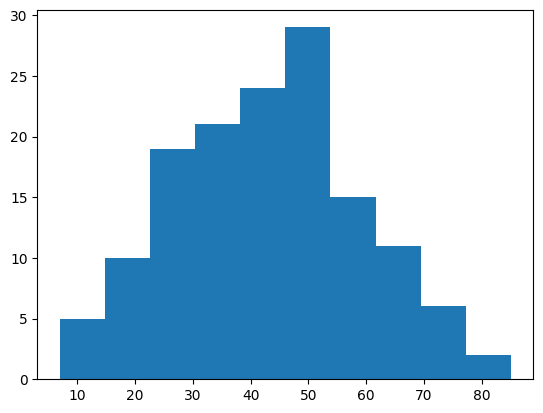

In [21]:
# Return an array with the ages of females
ages = np.array(data[data['Gender'] == 'Female']['Age'])
plt.hist(ages)
plt.show()

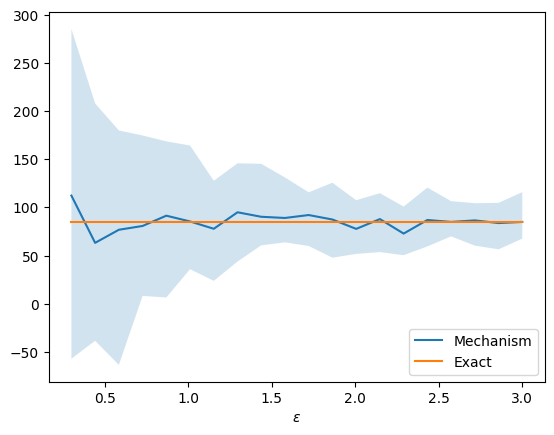

In [22]:
def maxLap(ages, eps):
    """
    Computes the differentially private maximum of an array of ages using the Laplace mechanism.

    Parameters:
    ages (numpy.ndarray): An array of ages.
    eps (float): The privacy parameter epsilon, which controls the amount of noise added.

    Returns:
    float: The differentially private maximum of the ages array.
    """
    # TODO: Done
    max_value = np.max(ages)
    sensitivity = 90
    noise = np.random.laplace(0, sensitivity/eps)
    noisy_max = max_value + noise
    return noisy_max


accuracy_plot(maxLap, ages, np.max(ages)) # will look very bad. 



The Laplace mechanism performs poorly for computing the maximum because the sensitivity of the max function is high (90), leading to large noise when \( \epsilon \) is small. This results in highly variable and often inaccurate estimates, making alternative methods like `maxLap2` or the Exponential Mechanism more suitable for this task.

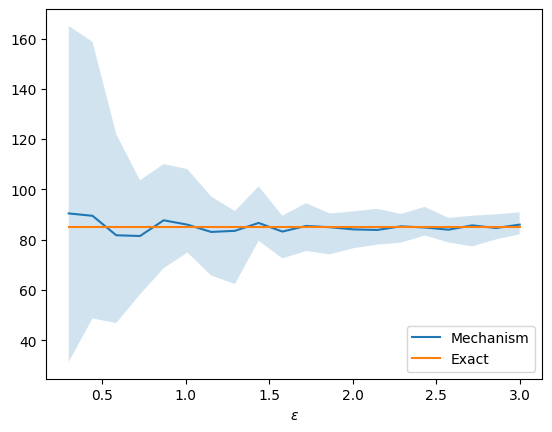

In [25]:
def maxLap2(ages, eps):
    # Another mechanism to return the differentially private uncensored max age
    guess = 80
    split = 1/4
    n = sum(ages >= guess) + np.random.laplace(0, 1/(split*eps))
    if (n > 1):
        dpmax = max(guess, np.max(ages)) + np.random.laplace(0, (90-guess)/((1-split)*eps)) # guess 10 
    else:
        dpmax = np.max(ages) + np.random.laplace(0, 90/((1-split)*eps)) # scale 90
    return dpmax

accuracy_plot(maxLap2, ages, np.max(ages)) # max 85, no correct, cuz i choose the mechan that depends on my data


Truncating the output between 0 and 90 is possible because the true age values are known to be within this range, meaning any values outside this bound result purely from added noise and can be safely corrected without violating differential privacy. The mechanism remains \(\epsilon\)-DP because the noise added follows the Laplace mechanism, and the probability of outputting any value remains proportional to \( e^{-\epsilon \Delta f}\), ensuring that no individual’s data significantly affects the result. This is in relation to composition theorem.

## L1.2 Differentially Private Arg Max

In this question, we will implement two mechanisms for reporting the id of the maximum of a feature. Specifically, we will implement algorithms that report the id of the most represented age categories among the females.

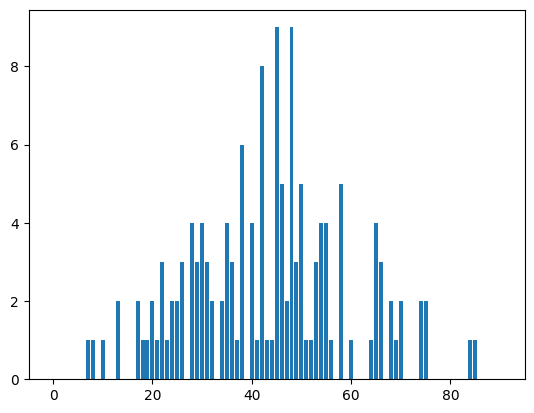

In [26]:
age_counts = np.array([np.sum(ages == i) for i in range(91)])
plt.bar(range(91), age_counts)
plt.show()  

### L1.2.1 Noisy Max with Laplace Mechanism

In [27]:
def reportNoisyArgMax(x, eps):
    """
    Computes the noisy argmax of an array using Laplace noise.

    This function adds Laplace noise to each element of the input array `x`
    and returns the index of the maximum value in the noisy array.

    Parameters:
    x (array-like): The input array for which the noisy argmax is to be computed.
    eps (float): The privacy parameter epsilon.

    Returns:
    int: The index of the maximum value in the noisy array.
    """
    # Calculate sensitivity (L1 sensitivity for single element perturbation)
    sensitivity = 1  # sensitivity of the index of the maximum value
    
    # Add Laplace noise to each element
    noisy_x = x + np.random.laplace(0, sensitivity / eps, size=len(x))
    
    # Return the index of the maximum value in the noisy array
    return np.argmax(noisy_x)

We can visualize the accuracy of the output of the `reportNoisyArgMax` method by running the mechanism several times and plotting the histogram of the ages corresponding to the returned indices.

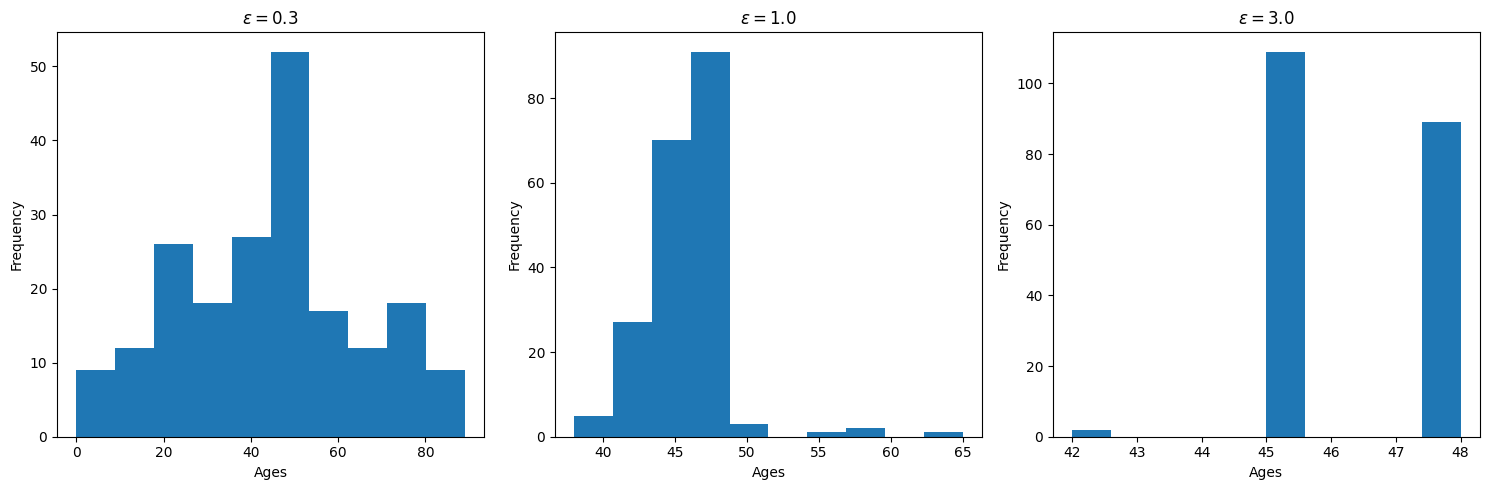

In [28]:
def accuracy_plot_for_argmax(mechanism, age_counts):
    eps_arr = np.array([0.3, 1, 3])
    num_iter = 200

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    for i, eps in enumerate(eps_arr):
        age_ids = [mechanism(age_counts, eps) for _ in range(num_iter)]
        axs[i].hist(age_ids)
        axs[i].set_xlabel('Ages')
        axs[i].set_ylabel('Frequency')
        axs[i].set_title('$\epsilon = {}$'.format(eps))

    plt.tight_layout()
    plt.show()

accuracy_plot_for_argmax(reportNoisyArgMax, age_counts)

Low epsilon values prioritize privacy but make the results less reliable and more spread out.

High epsilon values prioritize accuracy but reduce privacy, making the output closely reflect the true maximum.

### L1.2.2 Noisy Max with the Exponential Mechanism

We now consider addressing the same task using the Exponential mechanism. **What is the natural utility function $u(x,y)$ and what is its sensitivity?**

**Implement the exponential mechanism with the chosen utility function and illustrate the accuracy of the mechanism using the same plots as before.**

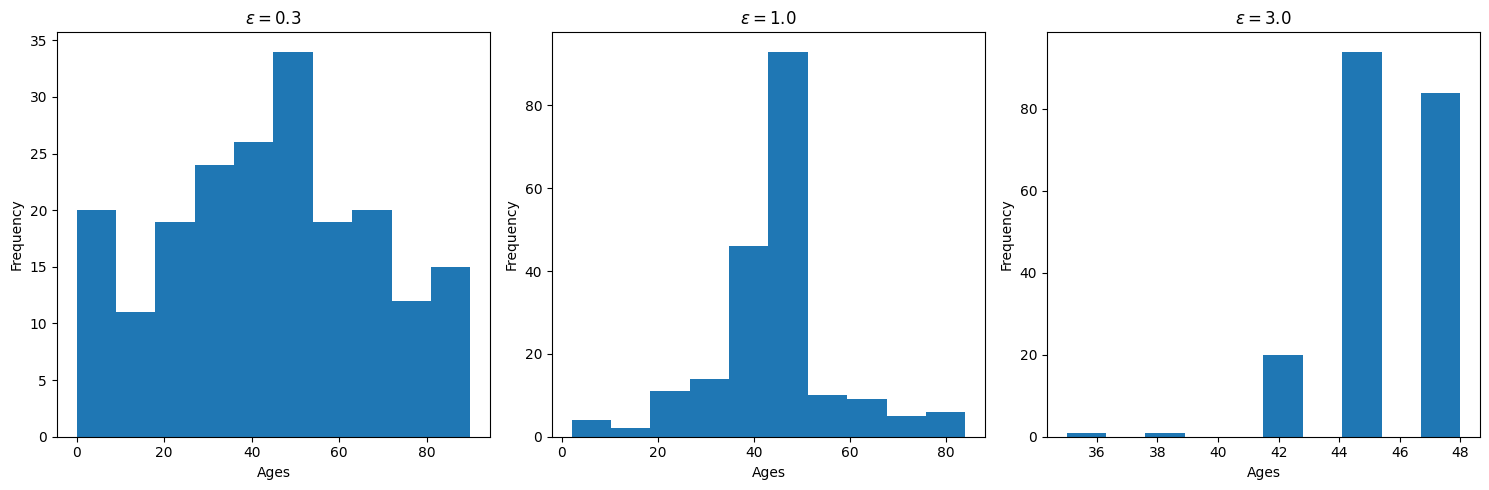

In [29]:
def argMaxExp(x, eps):
    """
    Computes the noisy argmax using the exponential mechanism.

    Parameters:
    x (array-like): The input array for which the noisy argmax is to be computed.
    eps (float): The privacy parameter epsilon.

    Returns:
    int: The index of the maximum value in the noisy array.
    """
    # Compute utilities (scaled by epsilon)
    utilities = x * eps / 2  # Scaling for exponential mechanism
    
    # Compute probabilities
    probabilities = np.exp(utilities - np.max(utilities))  # Stabilize with max subtraction
    probabilities /= np.sum(probabilities)
    
    # Sample from the probability distribution
    return np.random.choice(len(x), p=probabilities)

# Generate accuracy plot
accuracy_plot_for_argmax(argMaxExp, age_counts)

The utility function used is simply the count of each age group in the dataset.

The Exponential Mechanism performs better by concentrating more on the true maximum age for epsilon =1 and epsilon = 3.

# Part 3


## Linear Regression

We will consider simple (i.e., one-dimensional) linear regression with `Albumin` as the regressor $x$ and `Total_Proteins` as the target $y$. We will consider that the data can be approximately normalized by the following transform, making in possible to assume that all $x_i$ and $y_i$ are in $(-1,1)$.

In [30]:
x = (np.array(data['Albumin']).reshape(-1, 1)-3)/3
y = (np.array(data['Total_Proteins']).reshape(-1, 1)-5)/5

## Linear Regression
Given $\{(x_i,y_i)\}_{i=1}^n$, the task is to find the parameters $(\beta_1, \beta_0)$ to fit the following linear model,
$y = \beta_1 x + \beta_0$.

Let $X$ denote the $n\times 2$ matrix whose first column is composed of $x_1, \ldots, x_n$ and second column composed of all ones. Let $\beta = [\beta_1 \ \beta_0]^T$. Recall that the ordinary least squares (OLS) solution to the problem is the following.

$$
\hat{\beta}_{OLS} = (X^TX)^{-1}X^Ty
=   \begin{bmatrix} 
    \sum_i x_i^2 & \sum_i x_i\\
    \sum_i x_i & n
    \end{bmatrix}^{-1}
    \begin{bmatrix} 
    \sum_i x_iy_i\\
    \sum_i y_i
    \end{bmatrix}
$$.


### Linear Regression with OLS

The following code block implements the function `linreg` that computes $\beta$ using the OLS formula above.

In [32]:
def linreg(x,y):
    """
    Performs linear regression using Ordinary Least Squares (OLS).
    Parameters:
    x (numpy.ndarray): A 1D array of input features.
    y (numpy.ndarray): A 1D array of target values.
    Returns:
    numpy.ndarray: A 1D array containing the coefficients (slope, intercept) of the linear regression model.
    """

    n = x.size

    # Compute statistics
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xy = np.matmul(x.T, y).item()
    sum_x2 = np.matmul(x.T, x).item()
    
    # Solve the normal equations
    xTx = np.array([[sum_x2, sum_x], [sum_x, n]])
    xTy = np.array([[sum_xy], [sum_y]])
    beta_ols = np.linalg.solve(xTx, xTy)

    return beta_ols

The following code blocks illustrate the result of the `linreg` function applied to the data.

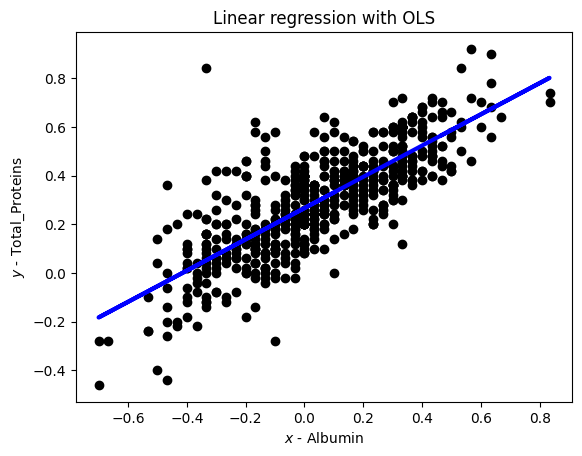

In [33]:
def plot_linreg(x, y, beta, title):
    yhat = beta[0]*x + beta[1]
    plt.scatter(x, y,  color='black')
    plt.plot(x, yhat, color='blue', linewidth=3)
    plt.xlabel(r'$x$ - Albumin')
    plt.ylabel(r'$y$ - Total_Proteins')
    plt.title(title)
    plt.show()

beta = linreg(x,y)
plot_linreg(x, y, beta,'Linear regression with OLS')

### L3.1 Perturbed Least Squares with Gaussian Mechanism

Given that the OLS solution is a function of the four statistics $\sum_i x_i^2, \sum_i x_i, \sum_i x_i y_i$ and $\sum_i y_i$, we will first consider using the Gaussian mechanism to perturb these statistics. **How should the scale of the Gaussian noise $\sigma$ be set so as to achieve $(\epsilon,\delta)$-DP with $\delta = 1/n$? Implement as `dp_linreg_pertub` a variant of  the `linreg`function above that implements this mechanism.** 

To apply the **Gaussian Mechanism** for differential privacy, we need to determine the **global sensitivity** of the four statistics used in ordinary least squares (OLS):

1. \( S_1 = \sum_{i=1}^{n} x_i^2 \) → Sensitivity: **1**
2. \( S_2 = \sum_{i=1}^{n} x_i \) → Sensitivity: **2**
3. \( S_3 = \sum_{i=1}^{n} x_i y_i \) → Sensitivity: **2**
4. \( S_4 = \sum_{i=1}^{n} y_i \) → Sensitivity: **2**

Given that the dataset is **bounded** with \( x_i, y_i \in [-1,1] \), the worst-case change when adding or removing a single data point is computed using the **L2 norm**:

\[
\Delta S = \sqrt{(1)^2 + (2)^2 + (2)^2 + (2)^2} = \sqrt{13}
\]




In [34]:
def dp_linreg_perturb(x, y, eps):
    """
    Performs (eps,1/n)-DP linear regression using Gauss Perturbed Least Squares.
    Parameters:
    x (numpy.ndarray): A 1D array of input features.
    y (numpy.ndarray): A 1D array of target values.
    eps (positive real): Privacy budget
    Returns:
    numpy.ndarray: A 1D array containing the coefficients (slope, intercept) of the linear regression model.
    """
    n = x.size

    # Compute original statistics
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xy = np.matmul(x.T, y).item()
    sum_x2 = np.matmul(x.T, x).item()

    # Compute noise scale based on Gaussian mechanism (delta = 1/n)
    delta = 1 / n
    sensitivity = np.sqrt(13)  

    sigma = (np.sqrt(2 * np.log(1 / delta)) * sensitivity) / eps

    # Add Gaussian noise to statistics
    sum_x2 += np.random.normal(0, sigma)
    sum_x += np.random.normal(0, sigma)
    sum_xy += np.random.normal(0, sigma)
    sum_y += np.random.normal(0, sigma)

    # Solve noisy normal equations
    xTx = np.array([[sum_x2, sum_x], [sum_x, n]])
    xTy = np.array([[sum_xy], [sum_y]])
    beta_gauss = np.linalg.solve(xTx, xTy)

    return beta_gauss


In the following code block, test the `dp_linreg_pertub` and compare its output with ordinary least squares.

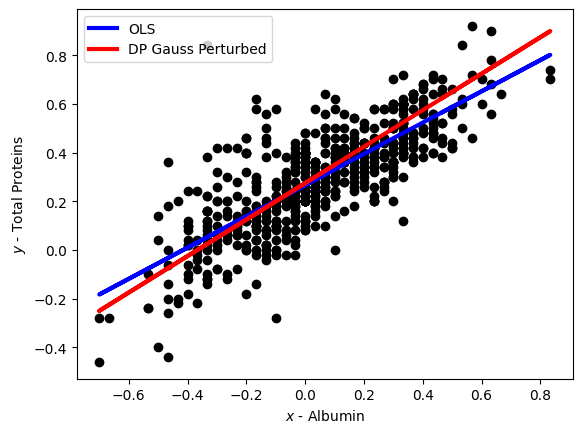

In [35]:
def plot_compar_linreg(x, y, beta1, title1, beta2, title2):
    yhat1 = beta1[0]*x + beta1[1]
    yhat2 = beta2[0]*x + beta2[1]

    plt.scatter(x, y,  color='black')
    plt.plot(x, yhat1, color='blue', linewidth=3, label=title1)
    plt.plot(x, yhat2, color='red', linewidth=3, label=title2)
    plt.legend(loc="upper left")
    plt.xlabel(r'$x$ - Albumin')
    plt.ylabel(r'$y$ - Total Proteins')
    plt.show()

eps = 3
plot_compar_linreg(x, y, linreg(x,y), 'OLS', dp_linreg_perturb(x, y, eps), 'DP Gauss Perturbed')

To measure the accuracy of the mechanism, we compute the median root mean squared error (RMSE) over multiple runs of the mechanism.

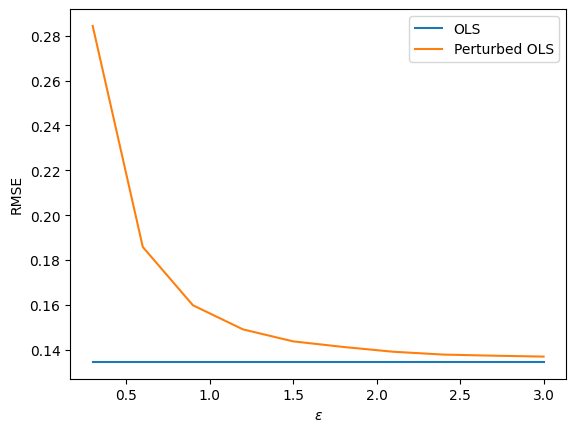

In [36]:
num_iter = 1000
eps_arr = np.linspace(0.3, 3, num=10)

beta_ols = linreg(x,y)
yhat_ols = beta_ols[0]*x + beta_ols[1]
rmse_ols = root_mean_squared_error(y, yhat_ols)*np.ones_like(eps_arr)
rmse = np.zeros((eps_arr.size, num_iter))

for i, eps in enumerate(eps_arr):
    for j in range(num_iter):
        beta = dp_linreg_perturb(x, y, eps)
        yhat = beta[0]*x + beta[1]   
        rmse[i][j] = root_mean_squared_error(y, yhat)

fig = plt.figure()
plt.plot(eps_arr, rmse_ols, label='OLS')
plt.plot(eps_arr, np.median(rmse, axis=1), label='Perturbed OLS')
plt.legend(loc="upper right")
plt.xlabel("$\epsilon$")
plt.ylabel("RMSE")
plt.show()

NB: As epsilon increases, the RMSE gradually approaches the OLS RMSE, since less noise is added.

### L3.2 Perturbed Gradient Descent

#### Gradient Descent

For this question, we will estimate $\hat{\beta}$ using gradient descent. Recall that in gradient descent, we start from an arbitraty initialization $\hat{\beta}_0$ for $\hat{\beta}$ and update $\hat{\beta}$ using the following equation.

$\hat{\beta}_{t+1} = \hat{\beta}_t - \gamma \nabla L(\hat{\beta}_t)$,

where $t$ is the iteration number running from $1$ to $T$ (maximum number of gradient steps), $\alpha$ is the step-size and $\nabla L(\hat{\beta}_t)$ is the gradient of the loss

$L(\beta) = \frac{1}{n} \sum_{i=1}^n (y_i - (\beta_0 x + \beta_1))^2$

evaluated at $\hat{\beta}_t$.

The following code block, implements the function `linreg_gd` that computes $\beta$ using gradient descent. Note that `linreg_gd` returns a list of $\hat{\beta}_t$ for each step $t$ of the gradient descent.

to calculate estimate the gradient it's better to:
 see taylor exp of first order
 delta beta * gradient = beta vector with perturbation
 

In [37]:
def linreg_gd(x, y, step_size, num_steps):
    '''
    Performs linear regression using gradient descent.
    Parameters:
    x (array of shape (n, 1)): Regressor
    y (array of shape (n, 1)): Target
    step_size (positive float): Step size for gradient descent
    num_steps (positive int (positive): Number of gradient descent steps
    Returns
    beta_list : list of length num_steps, where each element is an array of shape (2, 1)
        beta_list[t] is the estimate beta at step t
        beta_list[t][0] is the slope
        beta_list[t][1] is the y-intercept
    '''      

    n = y.size
    beta = np.zeros((2,1))
    beta_list = [beta]

    for i in range(num_steps):
        yhat = beta[0]*x + beta[1] # slope * x + intercept
        grad = np.zeros_like(beta)
        grad[0] = -2*np.mean((y - yhat)*x)
        grad[1] = -2*np.mean(y - yhat)
        beta = beta - step_size*grad
        beta_list.append(beta)

    return beta_list

The following code block illustrates the convergence of gradient descent. 

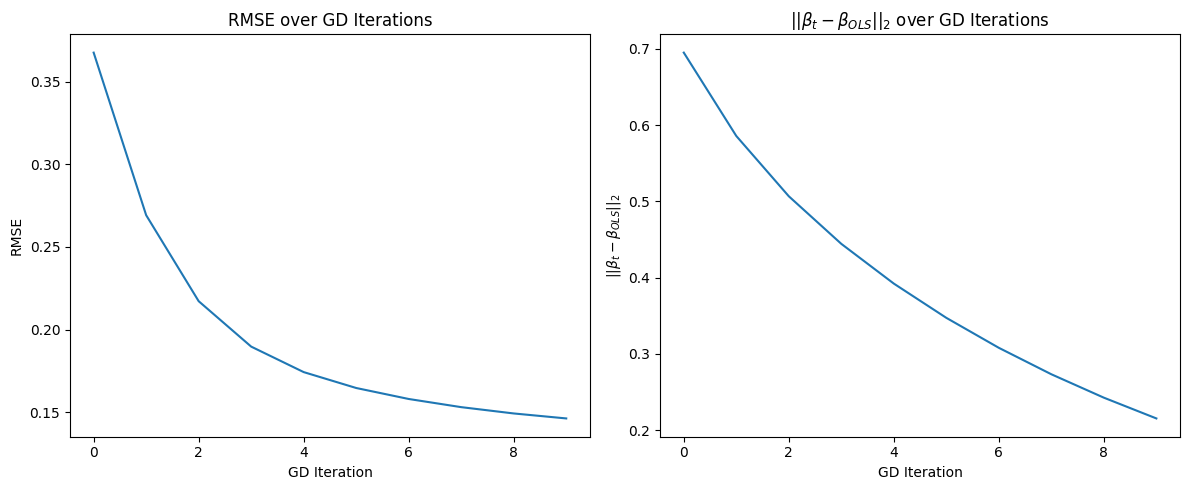

In [39]:
num_steps = 10
step_size = 0.8

beta_ols = linreg(x, y)
beta_gd = linreg_gd(x, y, step_size, num_steps)

rmse_gd = np.zeros(num_steps)
err_beta_gd = np.zeros(num_steps)

for i in range(num_steps):
    yhat = beta_gd[i][0]*x + beta_gd[i][1]
    rmse_gd[i] = root_mean_squared_error(y, yhat)
    err_beta_gd[i] = np.linalg.norm(beta_gd[i] - beta_ols)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(rmse_gd)
ax1.set_xlabel('GD Iteration')
ax1.set_ylabel('RMSE')
ax1.set_title('RMSE over GD Iterations')

ax2.plot(err_beta_gd)
ax2.set_xlabel('GD Iteration')
ax2.set_ylabel(r'$||\beta_t - \beta_{OLS}||_2$')
ax2.set_title(r'$||\beta_t - \beta_{OLS}||_2$ over GD Iterations')

plt.tight_layout()
plt.show()

#### Q2.4 Differentially Private Gradient Descent (DP-GD)



Gradient Sensitivity
Given the assumptions:
* $x_i, y_i \in [-1,1]$ (data bounds)
* $\beta_0, \beta_1 \in [-1,1]$ (parameter bounds)

For sensitivity, we need the L2 norm of gradient difference when changing one point:

* For any point $(x,y)$, its contribution to gradient is:
  * For $\beta_1$: $-\frac{2}{n}(y - (\beta_1x + \beta_0))x$
  * For $\beta_0$: $-\frac{2}{n}(y - (\beta_1x + \beta_0))$

* Maximum contribution difference (L2 norm):
  * $|y - (\beta_1x + \beta_0)| \leq 3$ (since $|y| \leq 1$ and $|\beta_1x + \beta_0| \leq 2$)
  * $|x| \leq 1$

Therefore L2 sensitivity of gradient: $\Delta_2 = \frac{6\sqrt{2}}{n}$

Privacy Budget for T Steps
For $(ε,δ)$-DP over T iterations:
* Using advanced composition theorem
* For T steps, per-step $ε_t = \frac{ε}{\sqrt{2T\ln(1/δ)}}$
* Total noise scale for each step: $σ = \frac{\Delta_2\sqrt{2\ln(1.25/δ)}}{ε_t}$

Substituting:
$σ = \frac{6\sqrt{2}}{n} \cdot \frac{\sqrt{2T\ln(1/δ)}}{ε} \cdot \sqrt{2\ln(1.25/δ)}$

In [40]:
def dp_linreg_gd(x, y, step_size, num_steps, eps):
    """
    Performs (ε, δ)-DP linear regression using Gaussian Perturbed Gradient Descent.

    Parameters:
    x (numpy.ndarray): A 1D array of input features.
    y (numpy.ndarray): A 1D array of target values.
    step_size (float): Step size for gradient descent.
    num_steps (int): Number of gradient descent steps.
    eps (float): Privacy budget.

    Returns:
    list: List of beta estimates at each step.
    """
    n = y.size
    delta = 1/n
    
    # Compute noise scale based on sensitivity and number of steps
    L = 3  # Lipschitz constant for our bounded problem
    sigma = (2 * L * np.sqrt(2.92 * num_steps * np.log(1/delta))) / eps
    
    beta = np.zeros((2,1))
    beta_list = [beta]
    
    for i in range(num_steps):
        # Compute gradient
        yhat = beta[0]*x + beta[1]
        grad = np.zeros_like(beta)
        grad[0] = -2*np.mean((y - yhat)*x)
        grad[1] = -2*np.mean(y - yhat)
        
        # Add calibrated Gaussian noise
        noise = np.random.normal(0, sigma, size=(2,1))
        grad = grad + noise
        
        # Update beta
        beta = beta - step_size*grad
        beta_list.append(beta)
    
    return beta_list



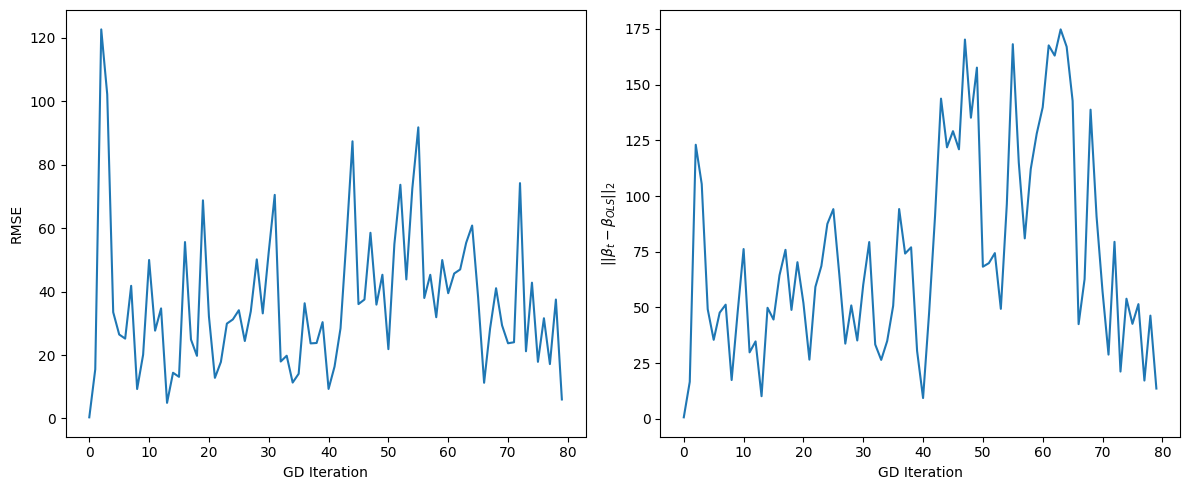

In [41]:
eps = 5
num_steps = 80
beta_list_dpgd = dp_linreg_gd(x, y, step_size, num_steps, eps)
rmse_dpgd = np.zeros(num_steps)
err_beta_dpgd = np.zeros(num_steps)
for i in range(num_steps):
    yhat = beta_list_dpgd[i][0]*x + beta_list_dpgd[i][1]
    rmse_dpgd[i] = root_mean_squared_error(y, yhat)
    err_beta_dpgd[i] = np.linalg.norm(beta_list_dpgd[i] - beta_ols)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(rmse_dpgd)
ax1.set_xlabel('GD Iteration')
ax1.set_ylabel('RMSE')

ax2.plot(err_beta_dpgd)
ax2.set_xlabel('GD Iteration')
ax2.set_ylabel(r'$||\beta_t - \beta_{OLS}||_2$')

plt.tight_layout()
plt.show()




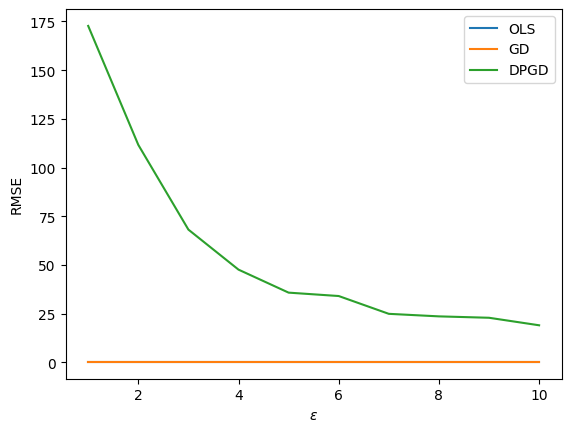

In [42]:

beta_ols = linreg(x, y)
yhat_ols = beta_ols[0]*x + beta_ols[1]
rmse_ols = root_mean_squared_error(y, yhat_ols)*np.ones_like(eps_arr)

beta_gd = linreg_gd(x, y, step_size, num_steps)[-1]
yhat_gd = beta_gd[0]*x + beta_gd[1]
rmse_gd = root_mean_squared_error(y, yhat_gd)*np.ones_like(eps_arr)                                    

num_iter = 100
eps_arr = np.linspace(1, 10, num=10)
rmse_dpgd = np.zeros((eps_arr.size, num_iter))

for i, eps in enumerate(eps_arr):
    for j in range(num_iter):
        beta_dpgd = dp_linreg_gd(x, y, step_size, num_steps, eps)[-1]
        yhat_dpgd = beta_dpgd[0]*x + beta_dpgd[1]   
        rmse_dpgd[i][j] = root_mean_squared_error(y, yhat_dpgd)

fig = plt.figure()
plt.plot(eps_arr, rmse_ols, label='OLS')
plt.plot(eps_arr, rmse_gd, label='GD')
plt.plot(eps_arr, np.median(rmse_dpgd, axis=1), label='DPGD')
plt.legend(loc="upper right")
plt.xlabel("$\epsilon$")
plt.ylabel("RMSE")
plt.show()

The previous approach assumed the worst-case bound for gradient sensitivity, which led to excessive noise being added in each step.
Since gradients can sometimes have large values due to outliers, the global L2 sensitivity bound can be unnecessarily large.
This excessive noise hurts convergence and leads to unstable results, especially for small epsilon

In [ ]:
def dp_linreg_gd_clipping(x, y, step_size, num_steps, eps, clip_norm):
    '''
    DP-GD with gradient norm-clipping ensuring (ε, δ)-DP.
    
    Parameters:
    x (numpy.ndarray): Input features.
    y (numpy.ndarray): Target values.
    step_size (float): Learning rate for gradient descent.
    num_steps (int): Number of gradient descent iterations.
    eps (float): Privacy budget.
    clip_norm (float): Clipping norm for gradients.
    
    Returns:
    beta_list (list): List of estimated beta values over iterations (each of shape (2, 1))
    
    ## Gradient Sensitivity
    Given the assumptions:
    * $x_i, y_i \in [-1,1]$ (data bounds)
    * $\beta_0, \beta_1 \in [-1,1]$ (parameter bounds)
    
    The L2 sensitivity of the gradient is:
    
    $$
    \Delta_2 = \frac{6\sqrt{2}}{n}
    $$
    
    ## Privacy Budget for T Steps
    Using advanced composition theorem, we allocate per-step privacy as:
    
    $$
    \epsilon_t = \frac{\epsilon}{\sqrt{2T\ln(1/\delta)}}
    $$
    
    The noise scale per step is:
    
    $$
    \sigma = \frac{6\sqrt{2}}{n} \cdot \frac{\sqrt{2T\ln(1/\delta)}}{\epsilon} \cdot \sqrt{2\ln(1.25/\delta)}
    $$
    '''
    
    n = y.size
    delta = 1 / n
    sensitivity = (6 * np.sqrt(2)) / n
    sigma = (sensitivity * np.sqrt(2 * num_steps * np.log(1 / delta)) * np.sqrt(2 * np.log(1.25 / delta))) / eps
    
    beta = np.zeros((2,1))
    beta_list = [beta]
    
    for i in range(num_steps):
        yhat = beta[0] * x + beta[1]
        grad = np.zeros_like(beta)
        grad[0] = -2 * np.mean((y - yhat) * x)
        grad[1] = -2 * np.mean(y - yhat)
        
        grad_norm = np.linalg.norm(grad)
        if grad_norm > clip_norm:
            grad = (grad / grad_norm) * clip_norm
        
        noise = np.random.normal(0, sigma, size=grad.shape)
        grad += noise
        
        beta = beta - step_size * grad
        beta_list.append(beta)
    
    return beta_list


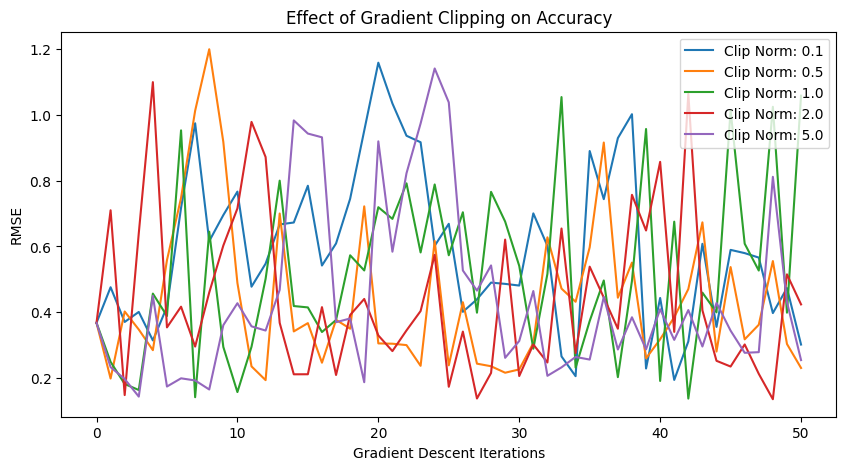

In [ ]:
# Function to evaluate RMSE of trained models
def evaluate_rmse(x, y, beta_list):
    rmse_values = []
    for beta in beta_list:
        yhat = beta[0] * x + beta[1]
        rmse = np.sqrt(np.mean((y - yhat) ** 2))
        rmse_values.append(rmse)
    return rmse_values

# Experimenting with different clipping values
clip_values = [0.1, 0.5, 1.0, 2.0, 5.0]
eps = 3  # Fixed privacy budget
num_steps = 50
step_size = 0.8

plt.figure(figsize=(10, 5))

for clip_norm in clip_values:
    beta_list = dp_linreg_gd_clipping(x, y, step_size, num_steps, eps, clip_norm)
    rmse_values = evaluate_rmse(x, y, beta_list)
    plt.plot(range(num_steps + 1), rmse_values, label=f"Clip Norm: {clip_norm}")

plt.xlabel("Gradient Descent Iterations")
plt.ylabel("RMSE")
plt.legend()
plt.title("Effect of Gradient Clipping on Accuracy")
plt.show()


In [ ]:

def dp_linreg_gd_adaptive(x, y, initial_step_size, num_steps, eps, clip_norm):
    '''
    DP-GD with adaptive step size and gradient norm-clipping ensuring (ε, δ)-DP.
    
    Parameters:
    x (numpy.ndarray): Input features.
    y (numpy.ndarray): Target values.
    initial_step_size (float): Initial step size.
    num_steps (int): Number of gradient descent steps.
    eps (float): Privacy budget.
    clip_norm (float): Clipping norm for gradients.
    
    Returns:
    beta_list (list): List of estimated beta values over iterations (each of shape (2, 1))
    '''
    
    n = y.size
    delta = 1 / n
    sensitivity = (6 * np.sqrt(2)) / n
    sigma = (sensitivity * np.sqrt(2 * num_steps * np.log(1 / delta)) * np.sqrt(2 * np.log(1.25 / delta))) / eps
    
    beta = np.zeros((2,1))
    beta_list = [beta]
    
    for t in range(1, num_steps + 1):
        step_size = initial_step_size / np.sqrt(t)
        yhat = beta[0] * x + beta[1]
        grad = np.zeros_like(beta)
        grad[0] = -2 * np.mean((y - yhat) * x)
        grad[1] = -2 * np.mean(y - yhat)
        
        grad_norm = np.linalg.norm(grad)
        if grad_norm > clip_norm:
            grad = (grad / grad_norm) * clip_norm
        
        noise = np.random.normal(0, sigma, size=grad.shape)
        grad += noise
        
        beta = beta - step_size * grad
        beta_list.append(beta)
    
    return beta_list


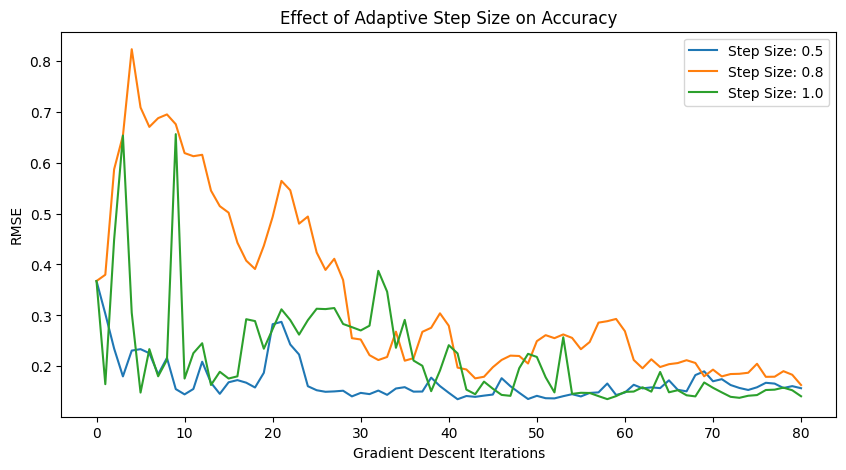

In [ ]:
step_sizes = [0.5, 0.8, 1.0]
num_steps = 80  # Increasing iterations
clip_norm = 1.0  # Best from previous experiment

plt.figure(figsize=(10, 5))

for step_size in step_sizes:
    beta_list = dp_linreg_gd_adaptive(x, y, step_size, num_steps, eps, clip_norm)
    rmse_values = evaluate_rmse(x, y, beta_list)
    plt.plot(range(num_steps + 1), rmse_values, label=f"Step Size: {step_size}")

plt.xlabel("Gradient Descent Iterations")
plt.ylabel("RMSE")
plt.legend()
plt.title("Effect of Adaptive Step Size on Accuracy")
plt.show()
